In [1]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345)

Part 1.)

In [99]:
#a.)

def H_0Likelyhood(MeasuredVelocity, H_0, Distance):
    exponent = -(MeasuredVelocity.n - (H_0*Distance))**2/(2*MeasuredVelocity.s**2)
    Likelyhood = 1/np.sqrt(2*np.pi*MeasuredVelocity.s**2) * np.exp(exponent)
    return(Likelyhood)

def Marginalization(MeasuredVelocity, H_0, Distance, H_0Prior):
    #now we integrate over H_0 to find p(Distance|Velocity)
    #This removes the nusiance parameter of H_0
    Posterior=[]
    for idx, i in enumerate(Distance):
        temp = np.trapz(H_0Likelyhood(MeasuredVelocity, H_0, i) * H_0Prior, x=H_0)
        Posterior.append(temp * DistancePrior[idx])
    
    Posterior=np.array(Posterior) #to array
    Posterior /= np.trapz(Posterior, x=Distance) #normalize the posterior
    return(Posterior)

def GaussianPrior(x, Location, Width):
    GaussianValues = np.exp(-(x - Location)**2/(2*Width**2)) #makes the gaussian
    GaussianValues /= np.trapz(GaussianValues, x=x) #normalizes
    return(GaussianValues)

def UniformPrior(x, Start, End):
    #This is ez pz as we know the bounds already(it's what I'm feeding in for Start and End)
    return(np.zeros(np.shape(x)) + 1/(End-Start))

Text(0, 0.5, 'Probability')

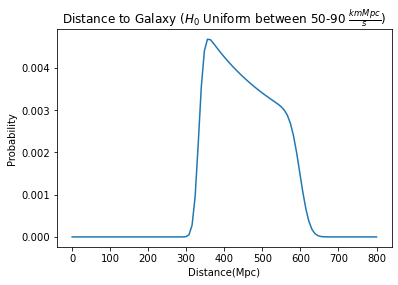

In [100]:
TestValuesDistance = np.linspace(0, 800, 100)
DistancePrior = UniformPrior(TestValuesDistance, 0, 800) #in Mpc

MeasuredVelocity = error.ufloat(30000, 1000) #in km/s

#This is part a specific
TestValuesH_0 = np.linspace(50, 90, 100)
H_0Prior = UniformPrior(TestValuesH_0, 50, 90) #in km/s/Mpc
Posterior = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0Prior)

plt.plot(TestValuesDistance, Posterior)
plt.title(r'Distance to Galaxy ($H_0$ Uniform between 50-90 $\frac{km Mpc}{s}$)')
plt.xlabel('Distance(Mpc)')
plt.ylabel('Probability')

Text(0, 0.5, 'Probability')

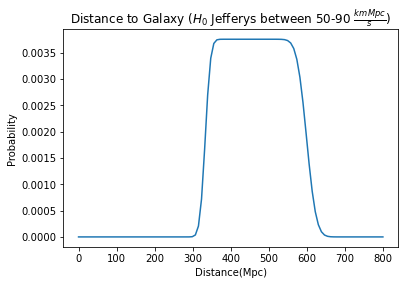

In [101]:
#b.)
TestValuesDistance = np.linspace(0, 800, 100)
DistancePrior = UniformPrior(TestValuesDistance, 0, 800) #in Mpc

MeasuredVelocity = error.ufloat(30000, 1000) #in km/s

#This is part b specific
def JefferysPrior(x, Start, Stop):
    #Jefferys for scale params is 1/param
    Prior = 1/x
    Prior /= np.trapz(Prior, x=x) #Normalize(should be by a factor of 1/ln(Stop-Start)) or something
    return(Prior)

TestValuesH_0 = np.linspace(50, 90, 100)
H_0Prior = JefferysPrior(TestValuesH_0, 50, 90) #in km/s/Mpc

Posterior = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0Prior)

plt.plot(TestValuesDistance, Posterior)
plt.title(r'Distance to Galaxy ($H_0$ Jefferys between 50-90 $\frac{km Mpc}{s}$)')
plt.xlabel('Distance(Mpc)')
plt.ylabel('Probability')

Text(0, 0.5, 'Probability')

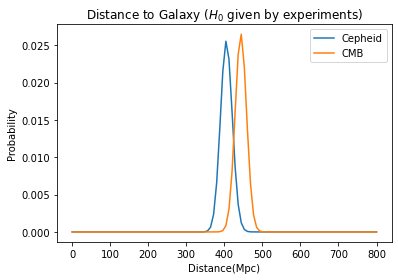

In [102]:
#c.)
TestValuesDistance = np.linspace(0, 800, 100)
DistancePrior = UniformPrior(TestValuesDistance, 0, 800) #in Mpc

MeasuredVelocity = error.ufloat(30000, 1000) #in km/s

#This is part c specific
TestValuesH_0 = np.linspace(50, 90, 1000)
H_0PriorCepheid = GaussianPrior(TestValuesH_0, 74.03, 1.42) #in km/s/Mpc
H_0PriorCMB = GaussianPrior(TestValuesH_0, 67.66, 0.42) #in km/s/Mpc

PosteriorCepheid = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0PriorCepheid)
PosteriorCMB = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0PriorCMB)

plt.plot(TestValuesDistance, PosteriorCepheid, label = 'Cepheid')
plt.plot(TestValuesDistance, PosteriorCMB, label='CMB')
plt.legend()
plt.title(r'Distance to Galaxy ($H_0$ given by experiments)')
plt.xlabel('Distance(Mpc)')
plt.ylabel('Probability')

Text(0, 0.5, 'Probability')

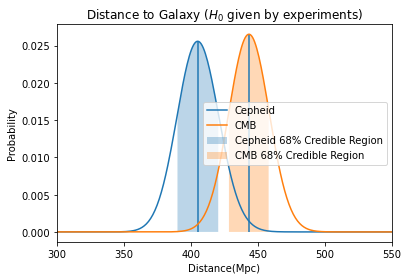

In [103]:
#d.)
#Copying over some code for a HDP, which is Central Credible Region provided there's monomodality
#AKA I'm lazy and just want to copy this over
def HDP(x, PDF, alpha):
    dx = np.diff(x)
    dx = np.append(dx, dx[-1]) #just to make same length. And leaving general for future homeworks
    #OK so the way I'm going about this is to sort by probability
    idx = np.argsort(PDF)[::-1] #in this case first is highest likelyhood, last is least likely
    temp = []
    cumulative = 0
    for i in idx: #ok so basically we sort the pdf by decreasing probability, and scan in new values if we haven't hit alpha
        cumulative += PDF[i] * dx[i]
        temp.append(i)
        if cumulative >= alpha:
            break
    temp = np.array(temp)
    #HPD is min/max value
    HDPmin = x[temp].min()
    HDPmax = x[temp].max()
    return(HDPmin, HDPmax) #This is probably overkill but this does account for everything

#Just zooming in on the specific region of interest here. Increasing posterior fidelity
TestValuesDistance = np.linspace(0, 800, 1000)
DistancePrior = UniformPrior(TestValuesDistance, 0, 800) #in Mpc
TestValuesH_0 = np.linspace(50, 90, 100)
H_0PriorCepheid = GaussianPrior(TestValuesH_0, 74.03, 1.42) #in km/s/Mpc
H_0PriorCMB = GaussianPrior(TestValuesH_0, 67.66, 0.42) #in km/s/Mpc

PosteriorCepheid = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0PriorCepheid)
PosteriorCMB = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0PriorCMB)
CepheidCCR = HDP(TestValuesDistance, PosteriorCepheid, alpha=0.68)
CMBCCR = HDP(TestValuesDistance, PosteriorCMB, alpha=0.68)

plt.plot(TestValuesDistance, PosteriorCepheid, label = 'Cepheid')
plt.plot(TestValuesDistance, PosteriorCMB, label='CMB')

#MPVs
plt.vlines(TestValuesDistance[np.argmax(PosteriorCepheid)], 0, np.max(PosteriorCepheid))
plt.vlines(TestValuesDistance[np.argmax(PosteriorCMB)], 0, np.max(PosteriorCMB))

#CepheidCCR
mask = (TestValuesDistance >= CepheidCCR[0]) & (TestValuesDistance <= CepheidCCR[1])
plt.fill_between(TestValuesDistance, PosteriorCepheid, where=mask, alpha=0.3, label='Cepheid 68% Credible Region')
#CMBCCR
mask = (TestValuesDistance >= CMBCCR[0]) & (TestValuesDistance <= CMBCCR[1])
plt.fill_between(TestValuesDistance, PosteriorCMB, where=mask, alpha=0.3, label='CMB 68% Credible Region')

plt.xlim(300, 550) #Focus on region of interest here
plt.legend()
plt.title(r'Distance to Galaxy ($H_0$ given by experiments)')
plt.xlabel('Distance(Mpc)')
plt.ylabel('Probability')

In [104]:
#d.)

#Computing the 68% central credible intervals for the measured galaxy using both the Cehpeid and CMB H_0 measurement,
#we see that they do not quite agree/overlap. However the 90% credible intervals will overlap.
#Because H_0 is a systematic, while it's own measurement may disagree significantly, it's effect on the distance calculation
#is less pronounced. H_0 errorbars will tend to spread the distance credible regions out, bluring the PDF
#This means that any uncertianty on H_0 makes the difference in distance calculations credible intervals smaller
#and this is compounded by the marginalization process

Part 2.)

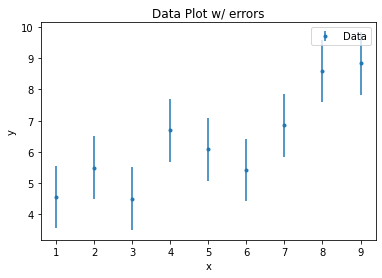

In [4]:
#This is my data input for the .txt files, may need to adjust the filepath
Data=pd.read_csv('HW7_Data/linear_data.txt', delim_whitespace=True)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

Optimized Slope: 0.4972999898640334
Optimized Yint: 3.850055579656032


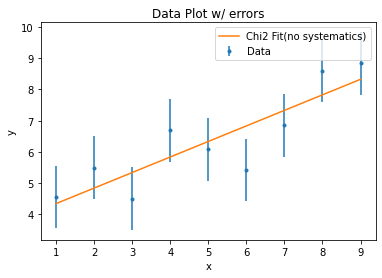

In [5]:
#a.)
#First thing we do is fit a linear function to this, assuming no systematics
#use chi2 minimization

#A frequentist approach. For this we will minimize chi2
def Chi2(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, Data):
    m, b = theta
    return Chi2(Data, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(Data,)) #some initial guesses
m_opt, b_opt = chi2minimized.x
print('Optimized Slope:', m_opt)
print('Optimized Yint:', b_opt)
plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], m_opt*Data['x'] + b_opt, label='Chi2 Fit(no systematics)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

Optimized Slope c=0.05: 0.5472999898601428
Optimized Yint c=0.05: 3.850055576293383
Optimized Slope c=-0.05: 0.44729999165009615
Optimized Yint c=-0.05: 3.8500555777951764


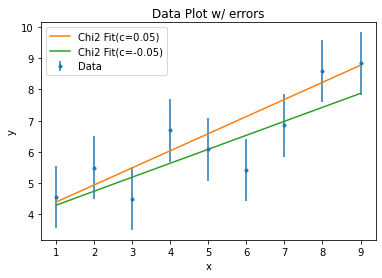

deltaa:
deltab:


In [6]:
#b.)
#We include a distorting systematic of deltay = cx + dx^2
#If we let d=0, c=+/-0.05, recalculate the fits

#Systematic uncertianties affect the measured values, so let's adjust those 
c=0.05
DataSystematicPlus = Data.copy()
DataSystematicMinus = Data.copy()
DataSystematicPlus['y'] = Data['y'] + c*Data['x']
DataSystematicMinus['y'] = Data['y'] - c*Data['x']

def Chi2Uncertianty(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, DataSystematic):
    m, b = theta
    return Chi2Uncertianty(DataSystematic, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicPlus,)) #some initial guesses
m_optcplus, b_optcplus = chi2minimized.x
print('Optimized Slope c=0.05:', m_optcplus)
print('Optimized Yint c=0.05:', b_optcplus)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicMinus,)) #some initial guesses
m_optcminus, b_optcminus = chi2minimized.x
print('Optimized Slope c=-0.05:', m_optcminus)
print('Optimized Yint c=-0.05:', b_optcminus)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(DataSystematicPlus['x'], m_optcplus*DataSystematicPlus['x'] + b_optcplus, label='Chi2 Fit(c=0.05)')
plt.plot(DataSystematicMinus['x'], m_optcminus*DataSystematicMinus['x'] + b_optcminus, label='Chi2 Fit(c=-0.05)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

Optimized Slope c=0.05: 0.5972999950953951
Optimized Yint c=0.05: 3.6667222097972467
Optimized Slope c=-0.05: 0.3972999980414052
Optimized Yint c=-0.05: 4.033388872418765


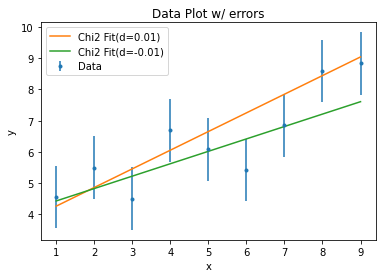

In [18]:
#c.)
#We include a distorting systematic of deltay = cx + dx^2
#If we let d=0, c=+/-0.05, recalculate the fits

#Systematic uncertianties affect the measured values, so let's adjust those 
d=0.01
DataSystematicPlus = Data.copy()
DataSystematicMinus = Data.copy()
DataSystematicPlus['y'] = Data['y'] + d*Data['x']**2
DataSystematicMinus['y'] = Data['y'] - d*Data['x']**2

def Chi2Uncertianty(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, DataSystematic):
    m, b = theta
    return Chi2Uncertianty(DataSystematic, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicPlus,)) #some initial guesses
m_optdplus, b_optdplus = chi2minimized.x
print('Optimized Slope c=0.05:', m_optdplus)
print('Optimized Yint c=0.05:', b_optdplus)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicMinus,)) #some initial guesses
m_optdminus, b_optdminus = chi2minimized.x
print('Optimized Slope c=-0.05:', m_optdminus)
print('Optimized Yint c=-0.05:', b_optdminus)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(DataSystematicPlus['x'], m_optdplus*DataSystematicPlus['x'] + b_optdplus, label='Chi2 Fit(d=0.01)')
plt.plot(DataSystematicMinus['x'], m_optdminus*DataSystematicMinus['x'] + b_optdminus, label='Chi2 Fit(d=-0.01)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

In [23]:
#Let's calculate deltaA and deltaB
deltaAplusc = m_opt - m_optcplus
deltaAminusc = m_opt - m_optcminus
deltaAplusd = m_opt - m_optdplus
deltaAminusd = m_opt - m_optdminus

deltaBplusc = b_opt - b_optcplus
deltaBminusc = b_opt - b_optcminus
deltaBplusd = b_opt - b_optdplus
deltaBminusd = b_opt - b_optdminus

print('deltaAplusc', deltaAplusc)
print('deltaAminusc', deltaAminusc)
print('deltaAplusd', deltaAplusd)
print('deltaAminusd', deltaAminusd)
print('deltaBplusc', deltaBplusc)
print('deltaBminusc', deltaBminusc)
print('deltaBplusd', deltaBplusd)
print('deltaBminusd', deltaBminusd)

#Now we average these to find the values we want

deltaB_c = 0.5 * (abs(deltaAplusc) + abs(deltaAminusc))
deltaB_d = 0.5 * (abs(deltaAplusd) + abs(deltaAminusd))
deltaA_c = 0.5 * (abs(deltaBplusc) + abs(deltaBminusc))
deltaA_d = 0.5 * (abs(deltaBplusd) + abs(deltaBminusd))

#And we add in quadrature

InterceptSystematic = np.sqrt(deltaB_c**2 + deltaB_d**2)
SlopeSystematic = np.sqrt(deltaA_c**2 + deltaA_c**2)

print('')
print('InterceptSystematic', InterceptSystematic)
print('SlopeSystematic', SlopeSystematic)

deltaAplusc -0.0678099776289321
deltaAminusc 0.03219002058111459
deltaAplusd -0.11780998286418437
deltaAminusd 0.08219001418980554
deltaBplusc 0.03265177374751316
deltaBminusc 0.0326517722457198
deltaBplusd 0.21598514024364945
deltaBminusd -0.15068152237786903

InterceptSystematic 0.11180339715724799
SlopeSystematic 0.046176580207342624


In [25]:
#We need statistical errors from the fit. Chi2 minimization doesnt give them so let's do scipy curve_fit
def Model(x, m, b):
    return m*x + b

popt, pcov = scipy.optimize.curve_fit(Model, Data['x'], Data['y'], sigma=Data['dy'], absolute_sigma=True)

m_opt, b_opt = popt
print(m_opt, b_opt)
SlopeStatistical = np.sqrt(pcov[0,0]) #diagonal values are sigma^2 for each value
InterceptStatistical = np.sqrt(pcov[1,1])

#From chi2 minimization
# Optimized Slope: 0.4972999898640334
# Optimized Yint: 3.850055579656032
#yeah we get basically the same thing for the optimized values. Just now with uncertinaty

0.4972999999989035 3.8500555555617724


In [28]:
#Now we can report things in the format you wanted
print('This is in format: estimator +/- StatisticalUncertianty +/- Systematic Uncertianty')
print('Slope:', m_opt, '+/-', SlopeStatistical, '+/-', SlopeSystematic)
print('Slope:', m_opt, '+/-', np.sqrt(SlopeStatistical**2 + SlopeSystematic**2))
print('')
print('Y-Intercept:', b_opt, '+/-', InterceptStatistical, '+/-', InterceptSystematic)
print('Y-Intercept:', b_opt, '+/-', np.sqrt(InterceptStatistical**2 + InterceptSystematic**2))

This is in format: estimator +/- StatisticalUncertianty +/- Systematic Uncertianty
Slope: 0.4972999999989035 +/- 0.12909944216241862 +/- 0.046176580207342624
Slope: 0.4972999999989035 +/- 0.13710923574396006

Y-Intercept: 3.8500555555617724 +/- 0.7264831487292357 +/- 0.11180339715724799
Y-Intercept: 3.8500555555617724 +/- 0.7350358936837345


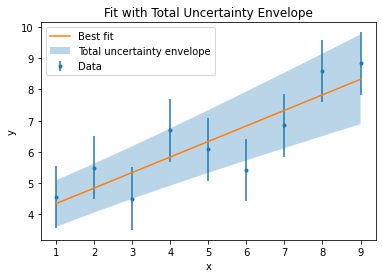

In [31]:
XAxis = np.linspace(min(Data['x']), max(Data['x']), 200)
YAxis = b_opt + m_opt * XAxis
SigmaSlope = np.sqrt(SlopeStatistical**2 + SlopeSystematic**2)
SigmaIntercept = np.sqrt(InterceptStatistical**2 + InterceptSystematic**2)

SigmaY = np.sqrt(SigmaSlope**2 * (XAxis**2) + SigmaIntercept**2) #We propagate the uncertianties into the line formula

yupper = YAxis + SigmaY #need an upper and lower to fill between
ylower = YAxis - SigmaY

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], fmt='.', label='Data') #Raw data
plt.plot(XAxis, YAxis, label='Best fit') #Best fit line
plt.fill_between(XAxis, ylower, yupper, alpha=0.3, label='Total uncertainty envelope') #uncertianty envelope
plt.title('Fit with Total Uncertainty Envelope')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

This concludes the delta method and now we do the pull method

In [46]:
#Pull Method
#In order to get the uncertianties we need later on we will need to do something to get covariance matrix
#I'm going to go through this here
def ModelFunction(theta, Data):
    m, b, c, d = theta #unpack
    Model = m*Data['x'] + b + c*Data['x'] + d*Data['x']**2 #linear with deltay from c and d terms
    Residue = (Data['y'] - Model) / Data['dy'] #difference between model and actual over errorbars
    Residue_c = c / 0.05 #over errorbars on these systematic terms
    Residue_d = d / 0.01
    return np.concatenate([Residue, [Residue_c, Residue_d]]) #weird format but it's useful next

result = scipy.optimize.least_squares(ModelFunction, x0=[0.5, 4, 0, 0], args=(Data,))
m_opt, b_opt, c_opt, d_opt = result.x
J = result.jac #Jacobian
cov = np.linalg.inv(J.T @ J) #(JJ^T)^-1 = Covariance. Also the @ making a comeback from quantum homeworks
#This is from https://en.wikipedia.org/wiki/Gauss%E2%80%93Newton_algorithm
#I just needed some way of getting the covariance from somewhere and this is the first process I found
#goes through a Hessian kinda. Interesting

sigma_m = np.sqrt(cov[0,0]) #sigma is the sqrt of the diagonals
sigma_b = np.sqrt(cov[1,1])

print('Slope:', m_opt, '+/-', sigma_m)
print('YInt:', b_opt, '+/-', sigma_b)

#Slope: 0.4972999999989035 +/- 0.13710923574396006
#Y-Intercept: 3.8500555555617724 +/- 0.7350358936837345
#Yeah ok this gets us values very similar to delta method

SlopeSystematicPull = np.sqrt(sigma_m**2 - SlopeStatistical**2)
InterceptSystematicPull = np.sqrt(sigma_b**2 - InterceptStatistical**2)

print('SlopeSystematicPull:', SlopeSystematicPull)
print('InterceptSystematicPull:', InterceptSystematicPull)

Slope: 0.4794898848790585 +/- 0.16990547159146518
YInt: 3.882707433277282 +/- 0.7485883982238866
SlopeSystematicPull: 0.1104590571663117
InterceptSystematicPull: 0.18057359875646092


part c.)

Optimized Slope: 0.4972999898640334
Optimized Yint: 3.850055579656032


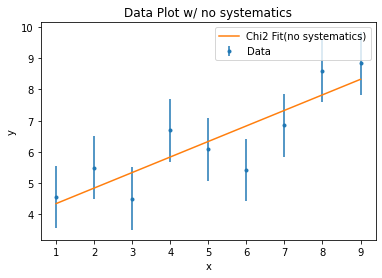

Optimized Slope c=0.05: 0.5472999898601428
Optimized Yint c=0.05: 3.850055576293383
Optimized Slope c=-0.05: 0.44729999165009615
Optimized Yint c=-0.05: 3.8500555777951764


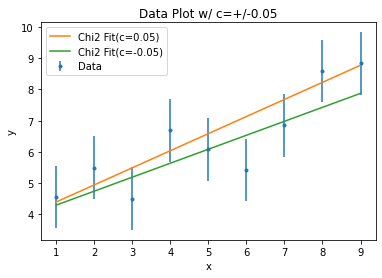

Optimized Slope c=0.05: 0.7972999906625693
Optimized Yint c=0.05: 3.3000555854167883
Optimized Slope c=-0.05: 0.19730000214154836
Optimized Yint c=-0.05: 4.400055536131342


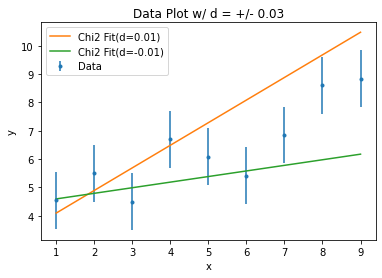

deltaAplusc -0.049999999996109434
deltaAminusc 0.04999999821393725
deltaAplusd -0.3000000007985359
deltaAminusd 0.29999998772248504
deltaBplusc 3.3626488260551923e-09
deltaBminusc 1.8608554697152613e-09
deltaBplusd 0.5499999942392435
deltaBminusd -0.5499999564753102

InterceptSystematic 0.30413812070638013
SlopeSystematic 3.693575309096349e-09
0.4972999999989035 3.8500555555617724
This is in format: estimator +/- StatisticalUncertianty +/- Systematic Uncertianty
Slope: 0.4972999999989035 +/- 0.12909944216241862 +/- 3.693575309096349e-09
Slope: 0.4972999999989035 +/- 0.12909944216241867

Y-Intercept: 3.8500555555617724 +/- 0.7264831487292357 +/- 0.30413812070638013
Y-Intercept: 3.8500555555617724 +/- 0.7875771466049237


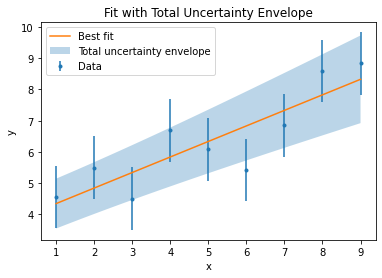

In [51]:
#Do it all again but with new c and d values
def Chi2(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, Data):
    m, b = theta
    return Chi2(Data, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(Data,)) #some initial guesses
m_opt, b_opt = chi2minimized.x
print('Optimized Slope:', m_opt)
print('Optimized Yint:', b_opt)
plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], m_opt*Data['x'] + b_opt, label='Chi2 Fit(no systematics)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ no systematics')
plt.show()

#We include a distorting systematic of deltay = cx + dx^2
#If we let d=0, c=+/-0.05, recalculate the fits

#Systematic uncertianties affect the measured values, so let's adjust those 
c=0.05
DataSystematicPlus = Data.copy()
DataSystematicMinus = Data.copy()
DataSystematicPlus['y'] = Data['y'] + c*Data['x']
DataSystematicMinus['y'] = Data['y'] - c*Data['x']

def Chi2Uncertianty(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, DataSystematic):
    m, b = theta
    return Chi2Uncertianty(DataSystematic, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicPlus,)) #some initial guesses
m_optcplus, b_optcplus = chi2minimized.x
print('Optimized Slope c=0.05:', m_optcplus)
print('Optimized Yint c=0.05:', b_optcplus)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicMinus,)) #some initial guesses
m_optcminus, b_optcminus = chi2minimized.x
print('Optimized Slope c=-0.05:', m_optcminus)
print('Optimized Yint c=-0.05:', b_optcminus)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(DataSystematicPlus['x'], m_optcplus*DataSystematicPlus['x'] + b_optcplus, label='Chi2 Fit(c=0.05)')
plt.plot(DataSystematicMinus['x'], m_optcminus*DataSystematicMinus['x'] + b_optcminus, label='Chi2 Fit(c=-0.05)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ c=+/-0.05')
plt.show()

d=0.03
DataSystematicPlus = Data.copy()
DataSystematicMinus = Data.copy()
DataSystematicPlus['y'] = Data['y'] + d*Data['x']**2
DataSystematicMinus['y'] = Data['y'] - d*Data['x']**2

def Chi2Uncertianty(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, DataSystematic):
    m, b = theta
    return Chi2Uncertianty(DataSystematic, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicPlus,)) #some initial guesses
m_optdplus, b_optdplus = chi2minimized.x
print('Optimized Slope c=0.05:', m_optdplus)
print('Optimized Yint c=0.05:', b_optdplus)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(DataSystematicMinus,)) #some initial guesses
m_optdminus, b_optdminus = chi2minimized.x
print('Optimized Slope c=-0.05:', m_optdminus)
print('Optimized Yint c=-0.05:', b_optdminus)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(DataSystematicPlus['x'], m_optdplus*DataSystematicPlus['x'] + b_optdplus, label='Chi2 Fit(d=0.01)')
plt.plot(DataSystematicMinus['x'], m_optdminus*DataSystematicMinus['x'] + b_optdminus, label='Chi2 Fit(d=-0.01)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ d = +/- 0.03')
plt.show()

#Let's calculate deltaA and deltaB
deltaAplusc = m_opt - m_optcplus
deltaAminusc = m_opt - m_optcminus
deltaAplusd = m_opt - m_optdplus
deltaAminusd = m_opt - m_optdminus

deltaBplusc = b_opt - b_optcplus
deltaBminusc = b_opt - b_optcminus
deltaBplusd = b_opt - b_optdplus
deltaBminusd = b_opt - b_optdminus

print('deltaAplusc', deltaAplusc)
print('deltaAminusc', deltaAminusc)
print('deltaAplusd', deltaAplusd)
print('deltaAminusd', deltaAminusd)
print('deltaBplusc', deltaBplusc)
print('deltaBminusc', deltaBminusc)
print('deltaBplusd', deltaBplusd)
print('deltaBminusd', deltaBminusd)

#Now we average these to find the values we want

deltaB_c = 0.5 * (abs(deltaAplusc) + abs(deltaAminusc))
deltaB_d = 0.5 * (abs(deltaAplusd) + abs(deltaAminusd))
deltaA_c = 0.5 * (abs(deltaBplusc) + abs(deltaBminusc))
deltaA_d = 0.5 * (abs(deltaBplusd) + abs(deltaBminusd))

#And we add in quadrature

InterceptSystematic = np.sqrt(deltaB_c**2 + deltaB_d**2)
SlopeSystematic = np.sqrt(deltaA_c**2 + deltaA_c**2)

print('')
print('InterceptSystematic', InterceptSystematic)
print('SlopeSystematic', SlopeSystematic)

#We need statistical errors from the fit. Chi2 minimization doesnt give them so let's do scipy curve_fit
def Model(x, m, b):
    return m*x + b

popt, pcov = scipy.optimize.curve_fit(Model, Data['x'], Data['y'], sigma=Data['dy'], absolute_sigma=True)

m_opt, b_opt = popt
print(m_opt, b_opt)
SlopeStatistical = np.sqrt(pcov[0,0]) #diagonal values are sigma^2 for each value
InterceptStatistical = np.sqrt(pcov[1,1])

#From chi2 minimization
# Optimized Slope: 0.4972999898640334
# Optimized Yint: 3.850055579656032
#yeah we get basically the same thing for the optimized values. Just now with uncertinaty

#Now we can report things in the format you wanted
print('This is in format: estimator +/- StatisticalUncertianty +/- Systematic Uncertianty')
print('Slope:', m_opt, '+/-', SlopeStatistical, '+/-', SlopeSystematic)
print('Slope:', m_opt, '+/-', np.sqrt(SlopeStatistical**2 + SlopeSystematic**2))
print('')
print('Y-Intercept:', b_opt, '+/-', InterceptStatistical, '+/-', InterceptSystematic)
print('Y-Intercept:', b_opt, '+/-', np.sqrt(InterceptStatistical**2 + InterceptSystematic**2))

XAxis = np.linspace(min(Data['x']), max(Data['x']), 200)
YAxis = b_opt + m_opt * XAxis
SigmaSlope = np.sqrt(SlopeStatistical**2 + SlopeSystematic**2)
SigmaIntercept = np.sqrt(InterceptStatistical**2 + InterceptSystematic**2)

SigmaY = np.sqrt(SigmaSlope**2 * (XAxis**2) + SigmaIntercept**2) #We propagate the uncertianties into the line formula

yupper = YAxis + SigmaY #need an upper and lower to fill between
ylower = YAxis - SigmaY

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], fmt='.', label='Data') #Raw data
plt.plot(XAxis, YAxis, label='Best fit') #Best fit line
plt.fill_between(XAxis, ylower, yupper, alpha=0.3, label='Total uncertainty envelope') #uncertianty envelope
plt.title('Fit with Total Uncertainty Envelope')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [50]:
#Pull Method
#In order to get the uncertianties we need later on we will need to do something to get covariance matrix
#I'm going to go through this here
def ModelFunction(theta, Data):
    m, b, c, d = theta #unpack
    Model = m*Data['x'] + b + c*Data['x'] + d*Data['x']**2 #linear with deltay from c and d terms
    Residue = (Data['y'] - Model) / Data['dy'] #difference between model and actual over errorbars
    Residue_c = c / 0.05 #over errorbars on these systematic terms
    Residue_d = d / 0.03
    return np.concatenate([Residue, [Residue_c, Residue_d]]) #weird format but it's useful next

result = scipy.optimize.least_squares(ModelFunction, x0=[0.5, 4, 0, 0], args=(Data,))
m_opt, b_opt, c_opt, d_opt = result.x
J = result.jac #Jacobian
cov = np.linalg.inv(J.T @ J) #(JJ^T)^-1 = Covariance. Also the @ making a comeback from quantum homeworks
#This is from https://en.wikipedia.org/wiki/Gauss%E2%80%93Newton_algorithm
#I just needed some way of getting the covariance from somewhere and this is the first process I found
#goes through a Hessian kinda. Interesting

sigma_m = np.sqrt(cov[0,0]) #sigma is the sqrt of the diagonals
sigma_b = np.sqrt(cov[1,1])

print('Slope:', m_opt, '+/-', sigma_m)
print('YInt:', b_opt, '+/-', sigma_b)

#Slope: 0.4972999999989035 +/- 0.13710923574396006
#Y-Intercept: 3.8500555555617724 +/- 0.7350358936837345
#Yeah ok this gets us values very similar to delta method

SlopeSystematicPull = np.sqrt(sigma_m**2 - SlopeStatistical**2)
InterceptSystematicPull = np.sqrt(sigma_b**2 - InterceptStatistical**2)

print('SlopeSystematicPull:', SlopeSystematicPull)
print('InterceptSystematicPull:', InterceptSystematicPull)

Slope: 0.3679326242858471 +/- 0.29938823079722077
YInt: 4.087229094632296 +/- 0.8744278115022635
SlopeSystematicPull: 0.2701233917550316
InterceptSystematicPull: 0.48666850333783995


In [ ]:
#Looking at the last plot, and the results we get for the slope and YInt, we can see there is a lot of noise to our signal
#espcially for slope. The error bar is now comparable to the estimated value
#If looking at the shaded region, we can imagine a line drawn from the top of the left side to the bottom of the right
#and it indeed would have very small slope.

#I would say that the d=+/-0.03 systematics seem comparable to the first set
#However, the pull method and the delta method differ greatly here, with the scale of the errorbars being ~factor of 2 different

#However these results do not seem unreasonable, and I personally would take the pull method more serious
#as it uses the Jacobian. Plus bigger errorbars in general seem more reasonable unless you can justify well why they wouldnt be
